# GWR Analysis - Obesity and Socio economic / Demographic 


## Install GAS Client SDK



In [ ]:
%pip install -q gas-client


## Imports

In [1]:
import os
from pathlib import Path
from urllib.parse import urljoin

from IPython.display import HTML, Image, display



from gas_client import GasClient

## User Settings

In [10]:
from dotenv import load_dotenv
import os
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent


server_url = "http://127.0.0.1:4042"
load_dotenv(project_root / ".env")
openai_api_key = os.environ["OPENAI_API_KEY"]
census_api_key = os.environ["US_CENSUS_API_KEY"]

timeout_seconds = 900

client = GasClient(
    server_url,
    openai_api_key=openai_api_key,
    artifact_delivery="URL",
)

credentials = {"OPENAI_API_KEY": openai_api_key}
download_parameters = {}
if census_api_key:
    download_parameters["US_Census_demography_key"] = census_api_key


## Discover Agents

In [3]:
client.list_agents()

['exploratory_spatial_data_analysis_agent',
 'geospatial_data_inspection_agent',
 'geospatial_data_retrieval_agent',
 'geospatial_workflow_planning_agent',
 'map_projection_agent',
 'mapping_agent',
 'pasda_agent',
 'raster_agent',
 'spatial_analysis_agent',
 'spatial_statistics_agent',
 'vector_analysis_agent',
 'web_mapping_app_agent']

In [4]:
data_agent = client.agent("geospatial_data_retrieval_agent")
vector_agent = client.agent("vector_analysis_agent")
mapping_agent = client.agent("mapping_agent")
web_mapping_app_agent = client.agent("web_mapping_app_agent")
esda_agent = client.agent("exploratory_spatial_data_analysis_agent")
spatial_analysis_agent = client.agent("spatial_analysis_agent")
spatial_statistics_agent = client.agent("spatial_statistics_agent")

for agent in [data_agent, vector_agent, mapping_agent, web_mapping_app_agent, esda_agent, spatial_analysis_agent, spatial_statistics_agent]:
    print(agent.agent_id, agent.status().get("status"))

geospatial_data_retrieval_agent available
vector_analysis_agent available
mapping_agent available
web_mapping_app_agent available
exploratory_spatial_data_analysis_agent available
spatial_analysis_agent available
spatial_statistics_agent available


## Helper Functions


In [ ]:
def absolute_url(url):
    if url.startswith("/"):
        return urljoin(server_url, url)
    return url


def all_artifact_urls(task_result):
    """Return every artifact URL from a task response, in order."""
    artifacts = task_result.get("outputs", {}).get("artifacts", []) or []
    return [absolute_url(a["url"]) for a in artifacts if a.get("url")]


def first_artifact_url(task_result, preferred_extensions=None):
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    preferred_extensions = preferred_extensions or []

    for extension in preferred_extensions:
        for artifact in artifacts:
            url = artifact.get("url")
            filename = artifact.get("filename") or artifact.get("name") or url or ""
            if url and str(filename).lower().endswith(extension.lower()):
                return absolute_url(url)

    for artifact in artifacts:
        if artifact.get("url"):
            return absolute_url(artifact["url"])

    raise RuntimeError("The task returned no artifact URL.")


def display_visual_artifacts(task_result):
    
    from urllib.request import urlopen

    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    for artifact in artifacts:
        url = artifact.get("url")
        filename = artifact.get("filename") or artifact.get("name") or ""
        if not url:
            continue
        display_url = absolute_url(url)
        lower_name = str(filename).lower()
        if lower_name.endswith((".png", ".jpg", ".jpeg", ".gif")):
            image_format = "jpeg" if lower_name.endswith((".jpg", ".jpeg")) else lower_name.rsplit(".", 1)[-1]
            try:
                with urlopen(display_url, timeout=120) as response:
                    image_bytes = response.read()
                display(Image(data=image_bytes, format=image_format))
            except Exception as exc:
                print(f"Could not embed image '{filename}' ({exc}); linking instead.")
                display(HTML(f'<a href="{display_url}" target="_blank">Open image artifact: {filename}</a>'))
        elif lower_name.endswith(".html"):
            display(HTML(f'<a href="{display_url}" target="_blank">Open interactive HTML artifact: {filename}</a>'))
        else:
            display(HTML(f'<a href="{display_url}" target="_blank">Open artifact: {filename}</a>'))


def display_geoprocessing_workflow(task_result, *, height=620):
    
    import html as _html
    from urllib.request import urlopen

    urls = all_artifact_urls(task_result)
    html_url = next((u for u in urls if u.lower().endswith(".html")), None)
    graphml_url = next((u for u in urls if u.lower().endswith((".graphml", ".gml"))), None)

    if html_url:
        print("Geoprocessing workflow:", html_url)
        try:
            with urlopen(html_url, timeout=120) as resp:
                doc = resp.read().decode("utf-8", errors="replace")
            srcdoc = _html.escape(doc, quote=True)
            iframe = (
                f'<iframe srcdoc="{srcdoc}" width="100%" height="{height}" '
                'style="border:1px solid #ddd; border-radius:6px;"></iframe>'
            )
            display({"text/html": iframe}, raw=True)
        except Exception as exc:
            print(f"Could not embed the workflow inline ({exc}).")
            display(HTML(f'<a href="{html_url}" target="_blank">Download the workflow HTML</a>'))
    elif graphml_url:
        print(
            "No interactive workflow HTML was returned. Restart the GAS server so it picks up the\n"
            "latest Spatial Analysis agent (which serves the workflow visualization as an artifact)."
        )
        display(HTML(f'<a href="{graphml_url}" target="_blank">Download the workflow GraphML</a>'))
    else:
        print("No workflow artifact (HTML or GraphML) was returned by the Spatial Analysis agent.")



def run_streaming_task(agent, instructions, *, input_datasets=None, parameters=None, title=None):
    if title:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    final_result = None
    for event in agent.execute_task(
        instructions,
        mode="stream",
        input_datasets=input_datasets,
        artifact_delivery="URL",
        credentials=credentials,
        parameters=parameters,
        timeout=timeout_seconds,
    ):
        client.print_stream_event(event)
        if event.get("event") == "task_result":
            final_result = event.get("payload")

    if final_result is None:
        raise RuntimeError("The stream ended before returning a task_result event.")

    client.print_task_summary(final_result)
    return final_result

## Part 1: Download Contiguous US County Boundaries

In [7]:
county_boundary_result = run_streaming_task(
    data_agent,
    (
        "(1) Use the US Census Bureau boundary source. Download county boundaries for West Virginia."
        "Return one clean GeoPackage dataset with county geometry, county name, state name or state abbreviation, STATEFP, COUNTYFP, and GEOID fields. "
                
        "(2) Download 2020 county-leveL obesity prevalence estimates "
        "for for West Virginia. Return one clean dataset with county FIPS/GEOID, county name, "
        "state identifier, year, measure name, and the obesity prevalence value. Geometry is optional for this "
        "dataset because it will be joined to a separate county boundary dataset."
    ),
    title="Download Contiguous US County Boundaries",
)

county_boundary_url = first_artifact_url(county_boundary_result, preferred_extensions=[".gpkg", ".geojson", ".json"])
county_boundary_url


Download Contiguous US County Boundaries
[19:53:00] stream_connected: Streaming connection established.
[19:53:00] Geospatial Data Retrieval Agent: I received your request.
[19:53:01] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[19:53:01] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[19:53:01] task_accepted: Task accepted. Starting streaming execution.
[19:53:01] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[19:53:01] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[19:53:03] Geospatial Data Retrieval Agent: The request was decomposed into 2 sub-request(s).
[19:53:03] Geospatial Data Retrieval Agent: I detected 2 datasets in your request. I will download each one as a separate sub-task and return all artifacts.
[19:53

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8575-qmji-9404.gpkg'

In [9]:
downloaded_urls = all_artifact_urls(county_boundary_result)
county_boundary_url, obesity_url = downloaded_urls[0], downloaded_urls[1]
print("County boundaries URL:", county_boundary_url)
print("Obesity prevalence URL:", obesity_url)

County boundaries URL: http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8575-qmji-9404.gpkg
Obesity prevalence URL: http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-3830-ewom-6178.csv


## Part 3: Join County Boundaries with Obesity Rates


In [10]:
obesity_join_result = run_streaming_task(
    vector_agent,
    (
        "Join the contiguous US county boundary dataset with the 2020 county-level adult obesity prevalence dataset. "
        "Use GEOID or county FIPS fields as the join key. Preserve county boundary geometry and key identifiers. "
        "Create a clean numeric field named obesity_rate for the obesity prevalence value. Keep county name, state, GEOID, "
        "year, and measure fields when available. Exclude unmatched non-contiguous records if present. Return one GeoJSON "
        "artifact ready for choropleth mapping."
    ),
    input_datasets=[county_boundary_url, obesity_url],
    title="Join County Boundaries and CDC Obesity Rates",
)

obesity_join_url = first_artifact_url(obesity_join_result, preferred_extensions=[".geojson", ".gpkg", ".json"])
obesity_join_url


Join County Boundaries and CDC Obesity Rates
[20:02:44] stream_connected: Streaming connection established.
[20:02:44] Vector Analysis Agent: I received your request.
[20:02:44] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[20:02:44] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[20:02:45] task_accepted: Task accepted. Starting streaming execution.
[20:02:45] Vector Analysis Agent: Next I will run the agent with the prepared inputs.
[20:02:45] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 2 dataset reference(s).
[20:02:45] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[20:02:45] Vector Analysis Agent: Joined 55 spatial features with 110 table/vector records using GEOID = c

'http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-3399-ejgn-6534.geojson'

## Part 4: Static Choropleth Map of County Obesity Rates



Create Static Obesity Rate Choropleth Map
[20:04:16] stream_connected: Streaming connection established.
[20:04:16] Mapping Agent: I received your request.
[20:04:17] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:04:17] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[20:04:17] task_accepted: Task accepted. Starting streaming execution.
[20:04:17] Mapping Agent: Next I will run the agent with the prepared inputs.
[20:04:17] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[20:04:17] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[20:04:27] Mapping Agent: I'm still working. Long LLM calls, code execution, or geospatial file processing ca

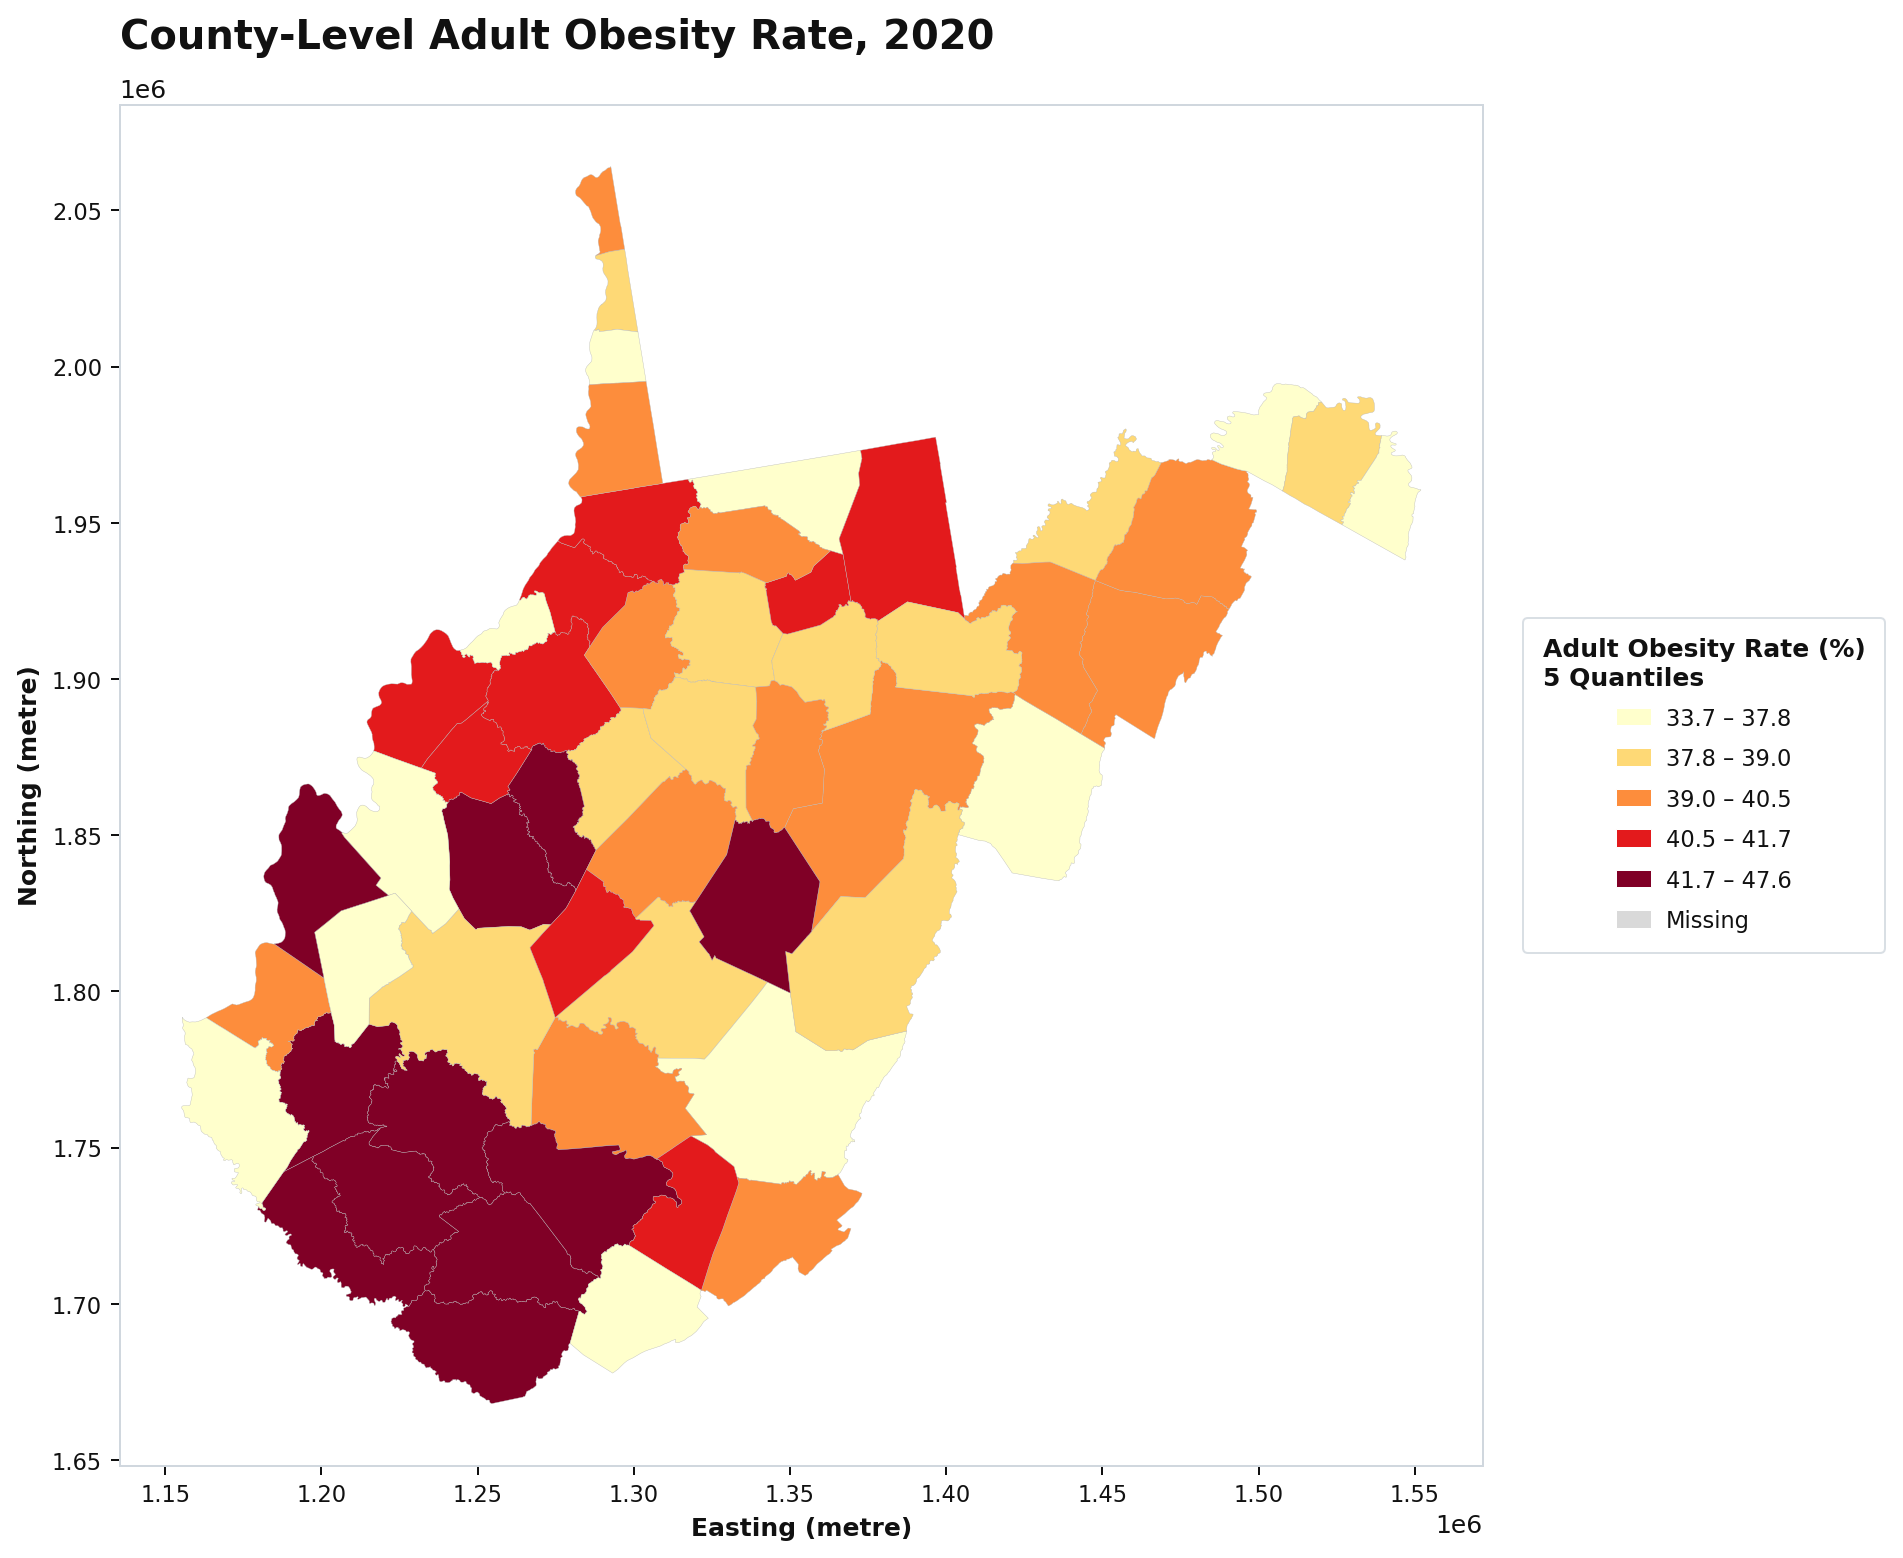

In [11]:
obesity_map_result = run_streaming_task(
    mapping_agent,
    (
        "Create a professional county-level choropleth map for the contiguous United States showing 2020 adult obesity rate. "
        "Use the obesity_rate field for color. Use 5 quantile classes, a clear sequential color scheme, thin county outlines, "
        "missing values in light gray, a legend outside the map axes, and the title 'County-Level Adult Obesity Rate, 2020'." \
        "Use the Albers Equal Area projection. " \
    ),
    input_datasets=[obesity_join_url],
    title="Create Static Obesity Rate Choropleth Map",
)

display_visual_artifacts(obesity_map_result)


## Part 5: Exploratory Spatial Data Analysis (ESDA) of County Obesity Rates


In [ ]:

esda_result = run_streaming_task(
    esda_agent,
    (
        "Using the joined county obesity dataset. Show the global spatial autocorrelation (Moran's I) of obesity_rate across the "
        "West Virginia counties."
    ),
    input_datasets=[obesity_join_url],
    title="Explore County Obesity Rates (ESDA)",
)




Explore County Obesity Rates (ESDA)
[20:31:14] stream_connected: Streaming connection established.
[20:31:14] Exploratory Spatial Data Analysis Agent: I received your request.
[20:31:15] Exploratory Spatial Data Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:31:15] Exploratory Spatial Data Analysis Agent: I found the required credentials and can start the model-backed workflow.
[20:31:15] task_accepted: Task accepted. Starting streaming execution.
[20:31:15] Exploratory Spatial Data Analysis Agent: Next I will run the agent with the prepared inputs.
[20:31:15] Exploratory Spatial Data Analysis Agent: I will profile the dataset(s), generate an ESDA script, execute it, and return an HTML report with charts.
[20:31:15] Exploratory Spatial Data Analysis Agent: I am profiling each dataset — shape, dtypes, missingness, and numeric/categorical/datetime/geometry classification.
[20:31:15] Exp

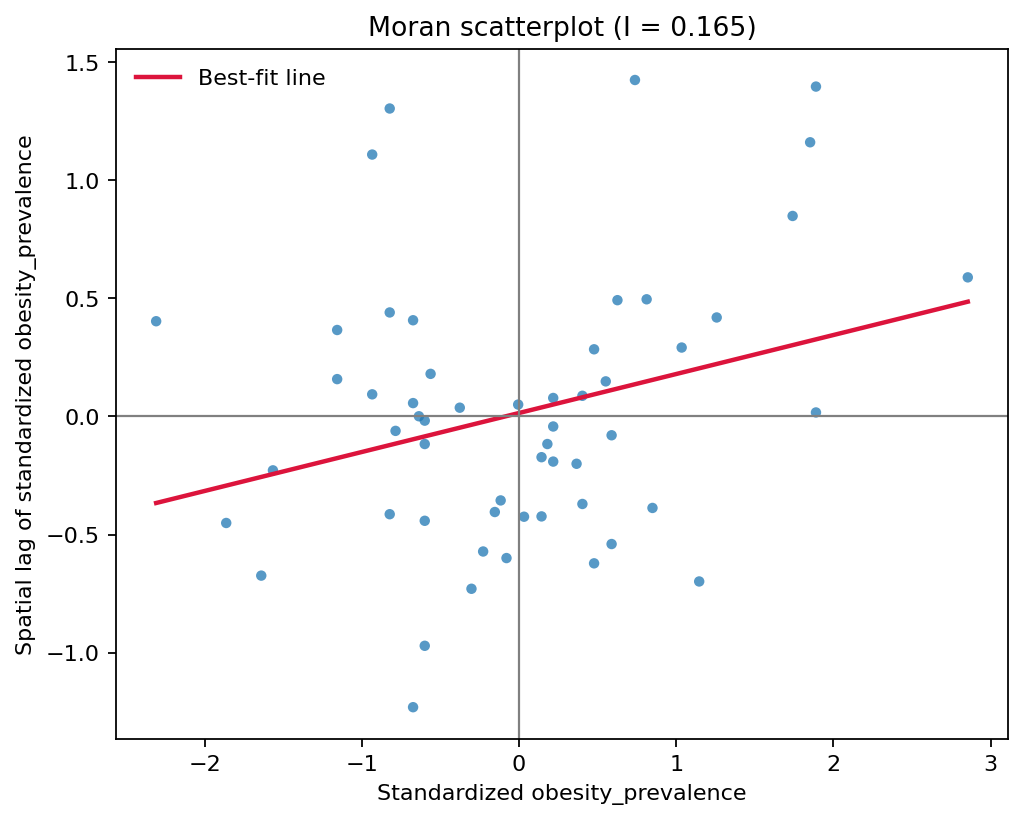

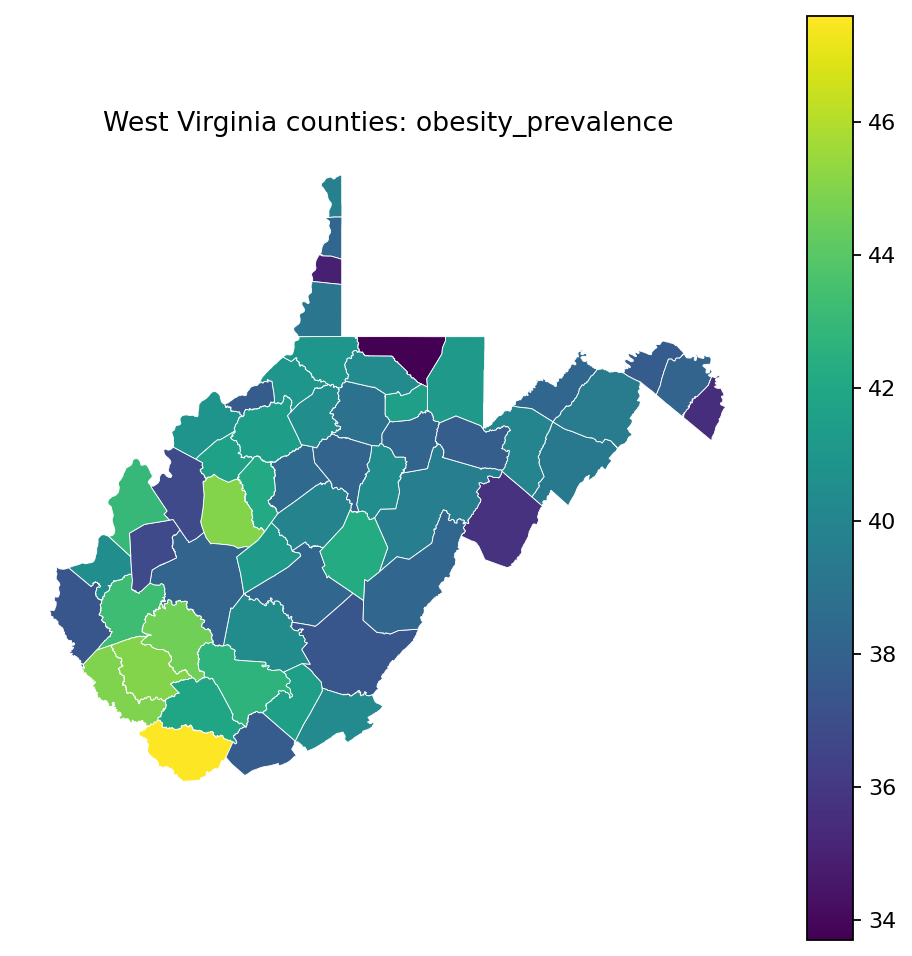

In [7]:
display_visual_artifacts(esda_result)

# Part 6: Download SES Factors

In [13]:
SES_result = run_streaming_task(
    data_agent,
    (
        "(1) Download Socioeconomic (Income and Poverty) for West Virginia."
        "Return one clean GeoPackage dataset with county geometry, county name, state name or state abbreviation, STATEFP, COUNTYFP, GEOID fields," 
        "and socioeconomic attributes"
        
        "(2) demographic data (Race, age, marital status, educational attainment) for West Virginia."
        "Return one clean GeoPackage dataset with county geometry, county name, state name or state abbreviation, STATEFP, COUNTYFP, GEOID fields," 
        "and demographic attributes"
        
    ),
    title="Download Socioeconomic and Demographic Data for West Virginia",
    parameters=download_parameters or None,
)

SES_url = first_artifact_url(SES_result, preferred_extensions=[".gpkg", ".geojson", ".json"])
SES_url


Download Socioeconomic and Demographic Data for West Virginia
[20:51:04] stream_connected: Streaming connection established.
[20:51:04] Geospatial Data Retrieval Agent: I received your request.
[20:51:04] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:51:04] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[20:51:04] task_accepted: Task accepted. Starting streaming execution.
[20:51:04] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[20:51:04] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[20:51:06] Geospatial Data Retrieval Agent: The request was decomposed into 2 sub-request(s).
[20:51:06] Geospatial Data Retrieval Agent: I detected 2 datasets in your request. I will download each one as a separate sub-task and return 

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-6402-gxhl-4101.gpkg'

# Join the SES data and the demographic data

In [17]:
SES_url = "http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-6402-gxhl-4101.gpkg"
Demographic_url = "http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-5974-ppbp-5455.gpkg"

SES_Demographic_join_result = run_streaming_task(
    vector_agent,
    (
        "Join the socioeconomic and demographic datasets. "
        "Use GEOID or county FIPS fields as the join key. Preserve county boundary geometry and key identifiers. "
        "Create a clean numeric field named obesity_rate for the obesity prevalence value. Keep county name, state, GEOID, "
        " Return one GeoJSON "
    ),
    input_datasets=[SES_url, Demographic_url],
    title="Join Obesity Socioeconomic data",
)

SES_Demographic_join_result_url = first_artifact_url(SES_Demographic_join_result, preferred_extensions=[".geojson", ".gpkg", ".json"])
SES_Demographic_join_result_url


Join Obesity Socioeconomic data
[21:10:49] stream_connected: Streaming connection established.
[21:10:49] Vector Analysis Agent: I received your request.
[21:10:49] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[21:10:49] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[21:10:50] task_accepted: Task accepted. Starting streaming execution.
[21:10:50] Vector Analysis Agent: Next I will run the agent with the prepared inputs.
[21:10:50] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 2 dataset reference(s).
[21:10:50] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[21:10:50] Vector Analysis Agent: Joined 55 spatial features with 55 table/vector records using GEOID = GEOID. Matched 

'http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-1690-wwrw-7408.geojson'

# Join All data

In [ ]:
obesity_SES_demographic_join_result = run_streaming_task(
    spatial_analysis_agent,
    (
        "Join the obesity_join dataset with the SES_demographic datasets. "
        "Use GEOID or county FIPS fields as the join key. Preserve county boundary geometry and key identifiers. "
        "Return a clean dataset with county name, state, GEOID, socioeconomic attributes, demographic attributes, and the obesity_rate field. "
        "Drop duplicate columns or unmatched records if present."
        
        " Return one GeoJSON "
    ),
    input_datasets=[obesity_join_url, SES_Demographic_join_result_url],
    title="Join Obesity Socioeconomic data",
)

obesity_SES_demographic_join_result_url = first_artifact_url(obesity_SES_demographic_join_result, preferred_extensions=[".geojson", ".gpkg", ".json"])
obesity_SES_demographic_join_result_url


Join Obesity Socioeconomic data
[21:18:12] stream_connected: Streaming connection established.
[21:18:12] Spatial Analysis Agent: I received your request.
[21:18:12] Spatial Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[21:18:12] Spatial Analysis Agent: I found the required credentials and can start the model-backed workflow.
[21:18:13] task_accepted: Task accepted. Starting streaming execution.
[21:18:13] Spatial Analysis Agent: Next I will run the agent with the prepared inputs.
[21:18:13] Spatial Analysis Agent: I will audit the input datasets, design a workflow DAG, generate code for each operation, assemble them into one program, and execute the program in a sandbox.
[21:18:13] Spatial Analysis Agent: I audited the input datasets and built a data registry with 2 entry/entries.
[21:18:13] Spatial Analysis Agent: I am asking the LLM to design a geoprocessing workflow DAG for the task

'http://127.0.0.1:4042/agents/spatial_analysis_agent/data/spatial_analysis_agent-6935-ekif-0107.geojson'

In [22]:
display_geoprocessing_workflow(obesity_SES_demographic_join_result)

Geoprocessing workflow: http://127.0.0.1:4042/agents/spatial_analysis_agent/data/spatial_analysis_agent-5221-jgqv-2096.html


<iframe srcdoc="<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Geoprocessing Workflow</title>
<script src="https://d3js.org/d3.v7.min.js"></script>
<style>
 body { margin:0; font-family:Segoe UI, Arial, sans-serif; background:#f8f9fa; display:flex; flex-direction:column; height:100vh; }
 h1 { text-align:center; padding:12px 0 4px; margin:0; font-size:18px; color:#2C3E50; }
 .subtitle { text-align:center; font-size:12px; color:#555; padding:0 24px 8px; }
 #graph { flex:1; overflow:hidden; position:relative; }
 svg { width:100%; height:100%; }
 .link { fill:none; stroke:#555; stroke-width:2; }
 .node { cursor:grab; }
 .node:active { cursor:grabbing; }
 .node:hover { filter:brightness(1.12) drop-shadow(0 0 6px rgba(0,0,0,.3)); }
 .node-label { pointer-events:none; font-family:Segoe UI, Arial, sans-serif; font-size:12px; font-weight:bold; text-anchor:middle; }
 .legend { position:absolute; bottom:10px; left:10px; background:#fff; border-radius:8px; padding:10px 14px; box-shadow:0 2px 8px rgba(0,0,0,.15); border:1px solid #ddd; font-size:11px; z-index:50; }
 .legend-item { display:flex; align-items:center; gap:8px; margin:4px 0; }
 .legend-swatch { width:28px; height:16px; border:1px solid #999; }
 .toolbar { position:absolute; top:10px; right:10px; display:flex; flex-direction:column; gap:4px; z-index:50; background:#fff; border-radius:8px; padding:6px; box-shadow:0 2px 8px rgba(0,0,0,.15); border:1px solid #ddd; }
 .tbtn { width:32px; height:32px; border:1px solid #ddd; border-radius:6px; background:#fff; cursor:pointer; font-size:15px; display:flex; align-items:center; justify-content:center; color:#444; padding:0; }
 .tbtn:hover { background:#e9ecef; }
 .popup-overlay { display:none; position:fixed; top:0; left:0; width:100%; height:100%; background:rgba(0,0,0,.35); z-index:100; justify-content:center; align-items:center; }
 .popup-overlay.visible { display:flex; }
 .popup-box { background:#fff; border-radius:10px; padding:24px 28px; max-width:580px; width:92%; max-height:75vh; overflow-y:auto; box-shadow:0 8px 32px rgba(0,0,0,.25); position:relative; animation:popIn .18s ease-out; }
 @keyframes popIn { from{transform:scale(.92);opacity:0} to{transform:scale(1);opacity:1} }
 .popup-box h3 { margin-top:0; color:#2C3E50; border-bottom:2px solid #4C72B0; padding-bottom:8px; }
 .popup-box p { line-height:1.6; color:#333; font-size:13px; }
 .popup-close { position:absolute; top:10px; right:14px; background:none; border:none; font-size:20px; color:#999; cursor:pointer; padding:4px 8px; border-radius:4px; }
 .popup-close:hover { background:#f0f0f0; color:#333; }
</style>
</head>
<body>
<h1>Geoprocessing Workflow</h1>
<div class="subtitle">Join the obesity_join dataset with the SES_demographic datasets. Use GEOID or county FIPS fields as the join key. Preserve county boundary geometry and key identifiers. Return a clean dataset with county name, state, GEOID, socioeconomic attributes, demographic attributes, and the obesity_rate field. Drop duplicate columns or unmatched records if present. Return one GeoJSON</div>
<div id="graph">
 <div class="toolbar">
 <button class="tbtn" id="zoomInBtn" title="Zoom in">+</button>
 <button class="tbtn" id="zoomOutBtn" title="Zoom out">&minus;</button>
 <button class="tbtn" id="fitBtn" title="Fit to view">&#9974;</button>
 <button class="tbtn" id="resetBtn" title="Reset layout">&#8634;</button>
 </div>
 <div class="legend">
 <div class="legend-item"><div class="legend-swatch" style="background:#6BA3D6;border-radius:8px"></div> Input Data</div>
 <div class="legend-item"><div class="legend-swatch" style="background:#F5D576;border-radius:3px"></div> Operation</div>
 <div class="legend-item"><div class="legend-swatch" style="background:#6BB56A;border-radius:8px"></div> Intermediate Data</div>
 <div class="legend-item"><div class="legend-swatch" style="background:#9B6DBF;border-radius:8px"></div> Final Output</div>
 </div>
</div>

<

## Part 6: GWR


In [23]:
GWR_result = run_streaming_task(
    spatial_statistics_agent,
    (
        "Fit a Geographically Weighted Regression (GWR) on the joined West Virginia county dataset "
        "- Dependent variable: obesity_rate. \n"
        "- Explanatory variables: the available numeric socioeconomic and demographic fields "
        "  (e.g. income, poverty, educational attainment, age, race, marital status). Ignore identifier, "
        "  geometry, year, and text columns, drop predictors that are constant or collinear, and clearly "
        "  report exactly which predictors were used. \n"
        "- Project to an equal-area CRS (EPSG:5070) for distances, standardize the predictors, and select "
        "  an adaptive bisquare bandwidth by golden-section search minimizing AICc. \n\n"
        "Return BOTH of the following so the results can be mapped and reviewed: \n"
        "1) A GeoPackage (named gwr_results.gpkg) AND a GeoJSON of the counties that KEEP the county "
        "   geometry and carry, per feature: GEOID, county name, the observed obesity_rate, the GWR "
        "   fitted value (gwr_yhat), the residual (gwr_residual) and standardized residual "
        "   (gwr_std_residual), the local R-squared (local_r2), the local intercept (coef_intercept), "
        "   one local coefficient column per predictor named coef_<variable>, and its local t-value "
        "   t_<variable>. This vector layer is the input a downstream mapping agent will use to map the "
        "   coefficients, local R-squared, and residuals. \n"
        "2) A polished HTML report summarizing the GWR fit: selected bandwidth, global and local "
        "   R-squared, AICc, effective number of parameters, per-predictor coefficient summary "
        "   (min / median / max and share significant), and a global Moran's I of the residuals to check "
        "   for remaining spatial autocorrelation. Embed small maps of the residuals and the key local "
        "   coefficients in the HTML report."
    ),
    input_datasets=[obesity_SES_demographic_join_result_url],
    title="Fit GWR of County Obesity Rate (Spatial Statistics)",
)

# Mappable layer (local coefficients, local R2, residuals) for the downstream mapping agent
gwr_urls = all_artifact_urls(GWR_result)
gwr_features_url = next((u for u in gwr_urls if u.lower().endswith((".gpkg", ".geojson", ".json"))), None)
gwr_report_url = next((u for u in gwr_urls if u.lower().endswith(".html")), None)




Fit GWR of County Obesity Rate (Spatial Statistics)
[21:31:49] stream_connected: Streaming connection established.
[21:31:50] Spatial Statistics Agent: I received your request.
[21:31:50] Spatial Statistics Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:31:50] Spatial Statistics Agent: I found the required credentials and can start the model-backed workflow.
[21:31:50] task_accepted: Task accepted. Starting streaming execution.
[21:31:50] Spatial Statistics Agent: Next I will run the agent with the prepared inputs.
[21:31:50] Spatial Statistics Agent: I will inspect the datasets, choose suitable PySAL methods, generate analysis code, and return a modeling report.
[21:31:50] Spatial Statistics Agent: I am inspecting the input datasets to identify geometry types, CRS, numeric fields, candidate modeling variables, and usable PySAL workflows.
[21:31:50] Spatial Statistics Agent: Dataset inspection

GWR mappable layer (-> mapping agent): http://127.0.0.1:4042/agents/spatial_statistics_agent/data/spatial_statistics_agent-1511-hhvu-6398.geojson
GWR HTML summary report             : http://127.0.0.1:4042/agents/spatial_statistics_agent/data/spatial_statistics_agent-3610-bqjh-2061.html


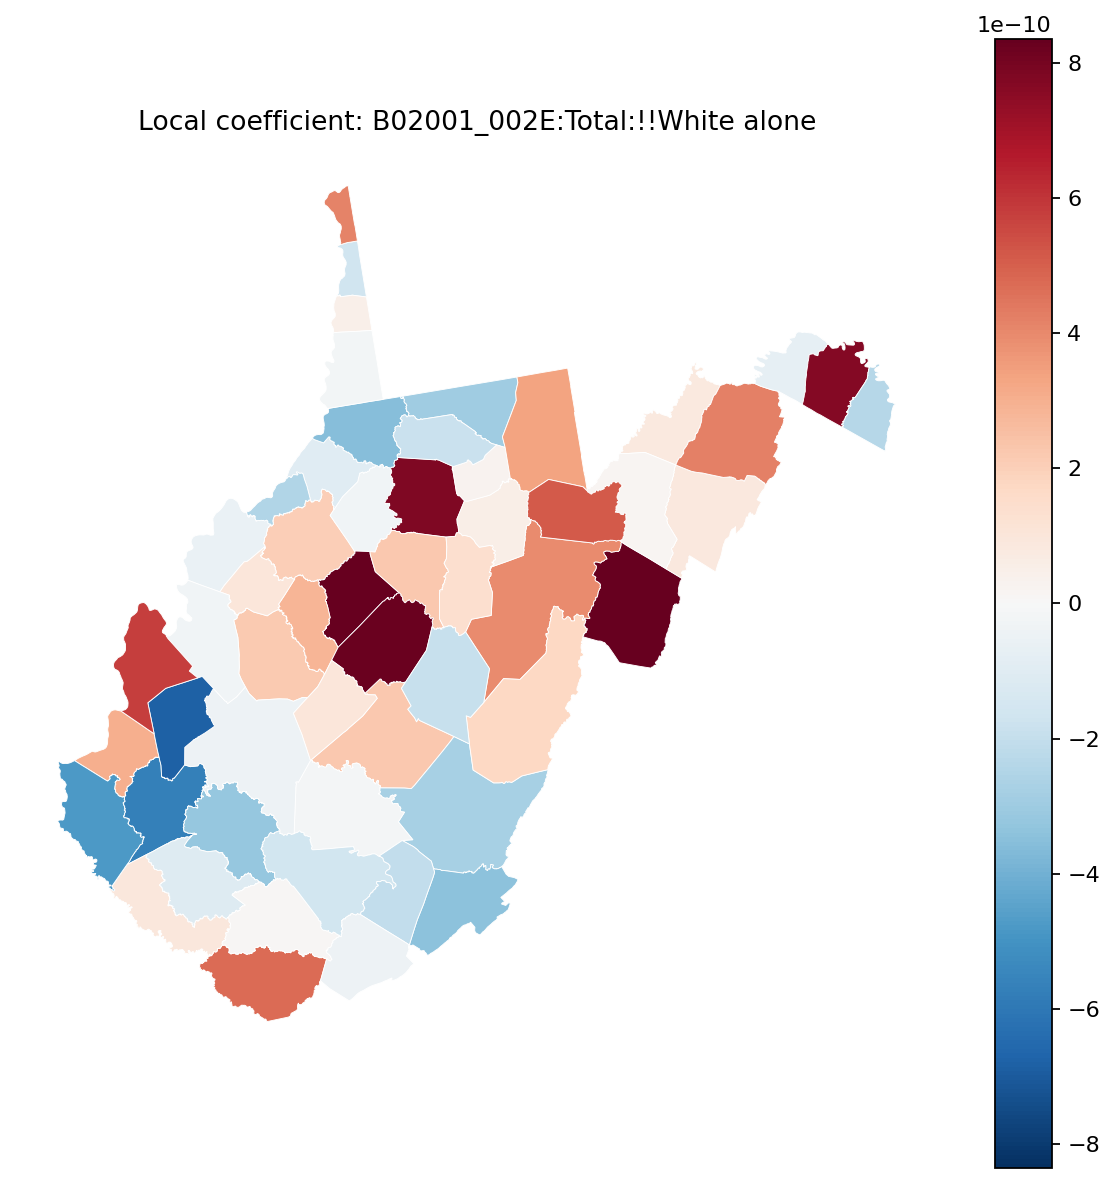

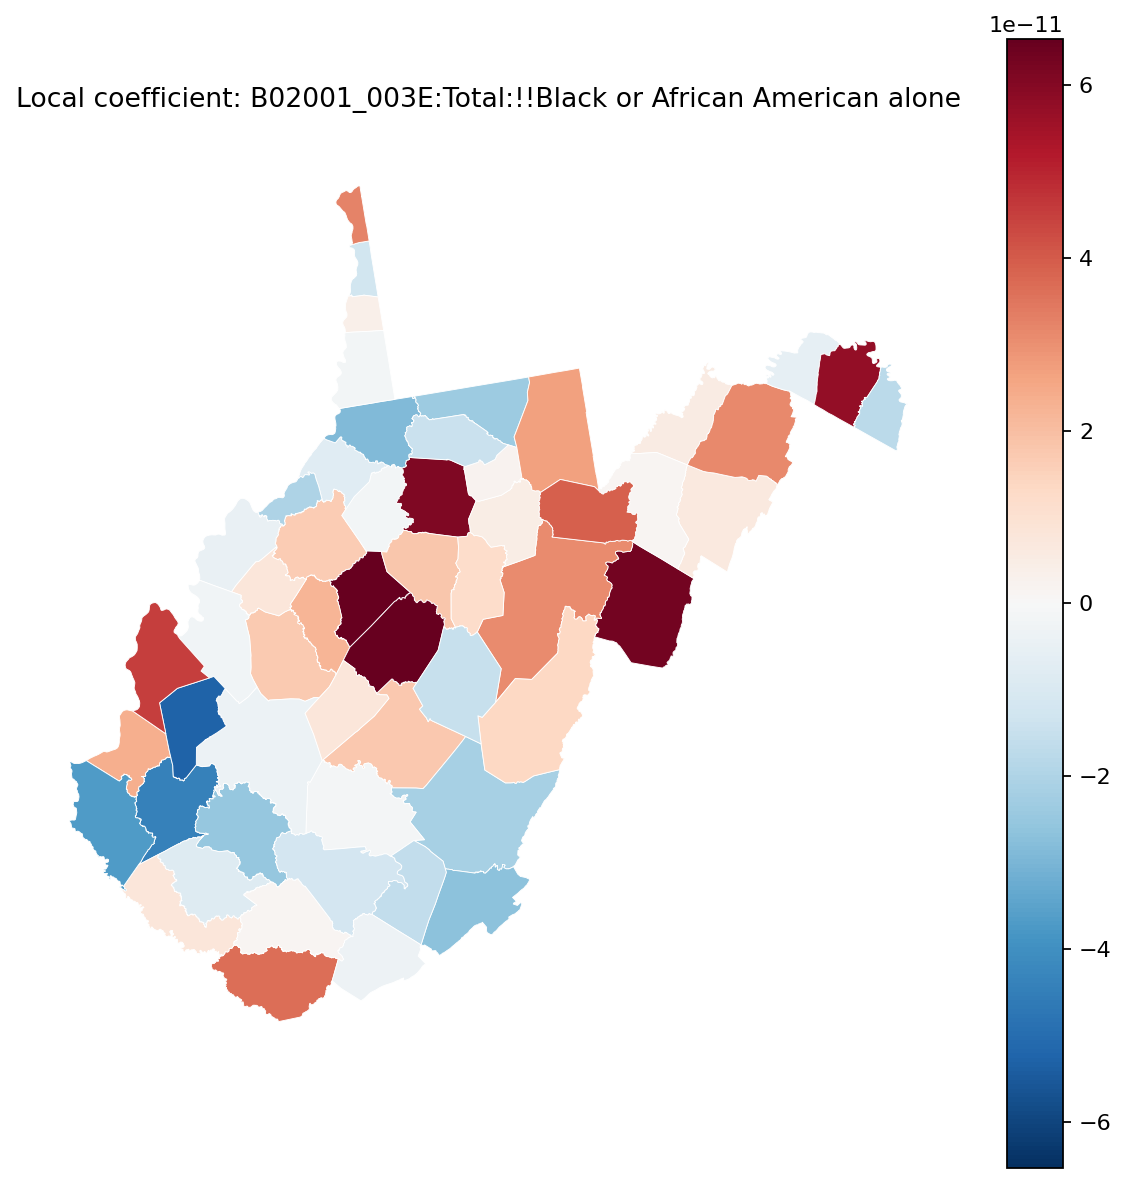

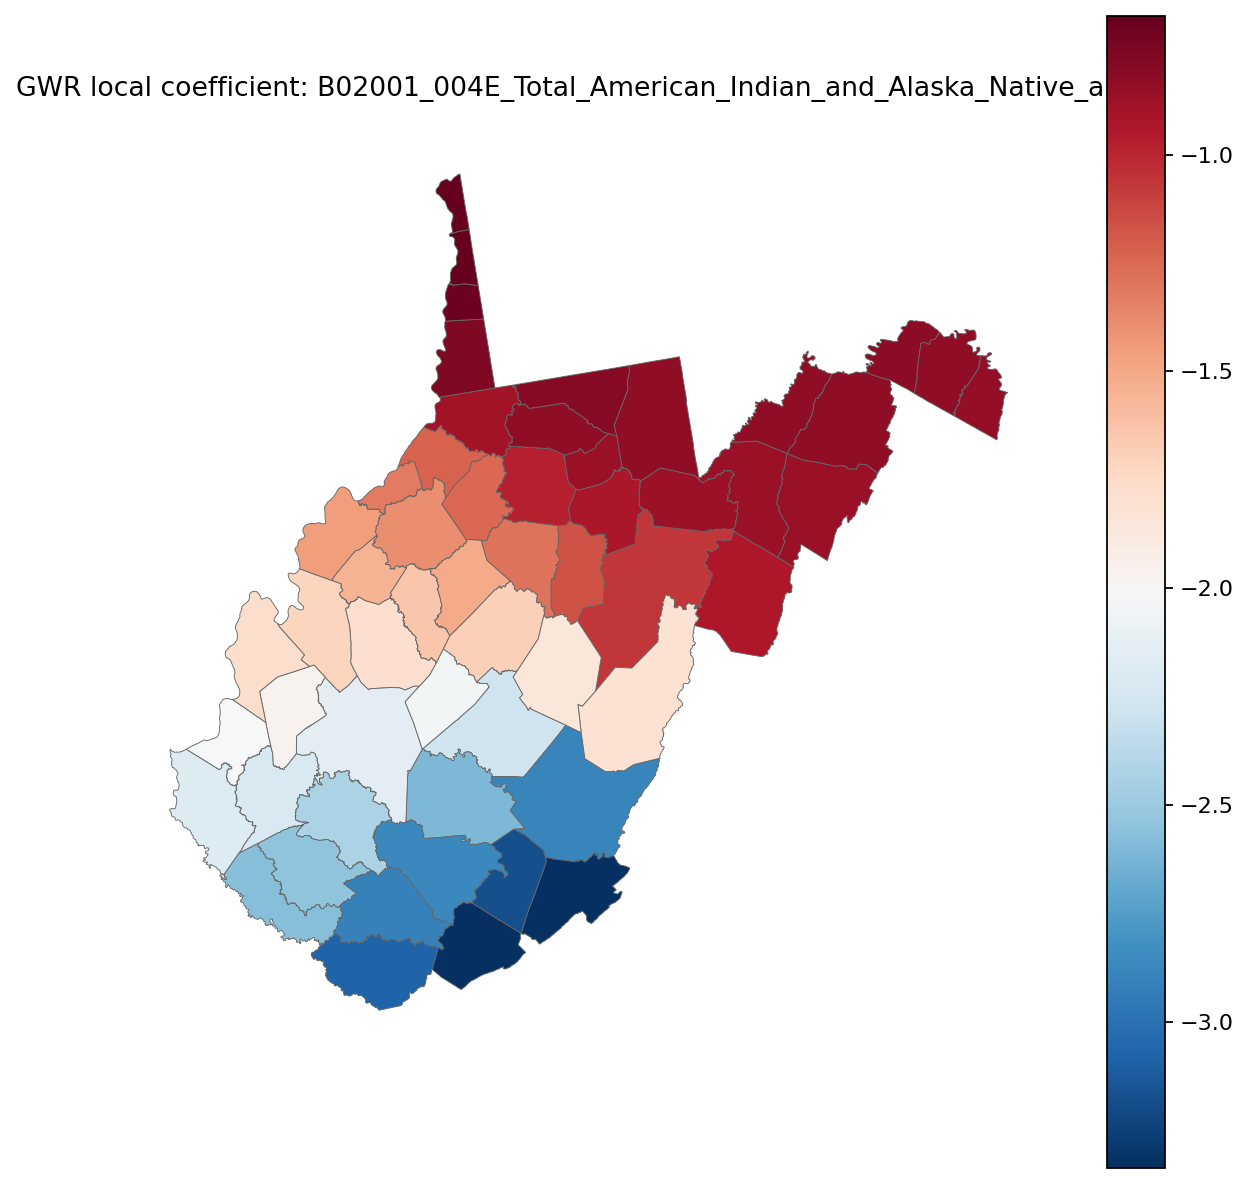

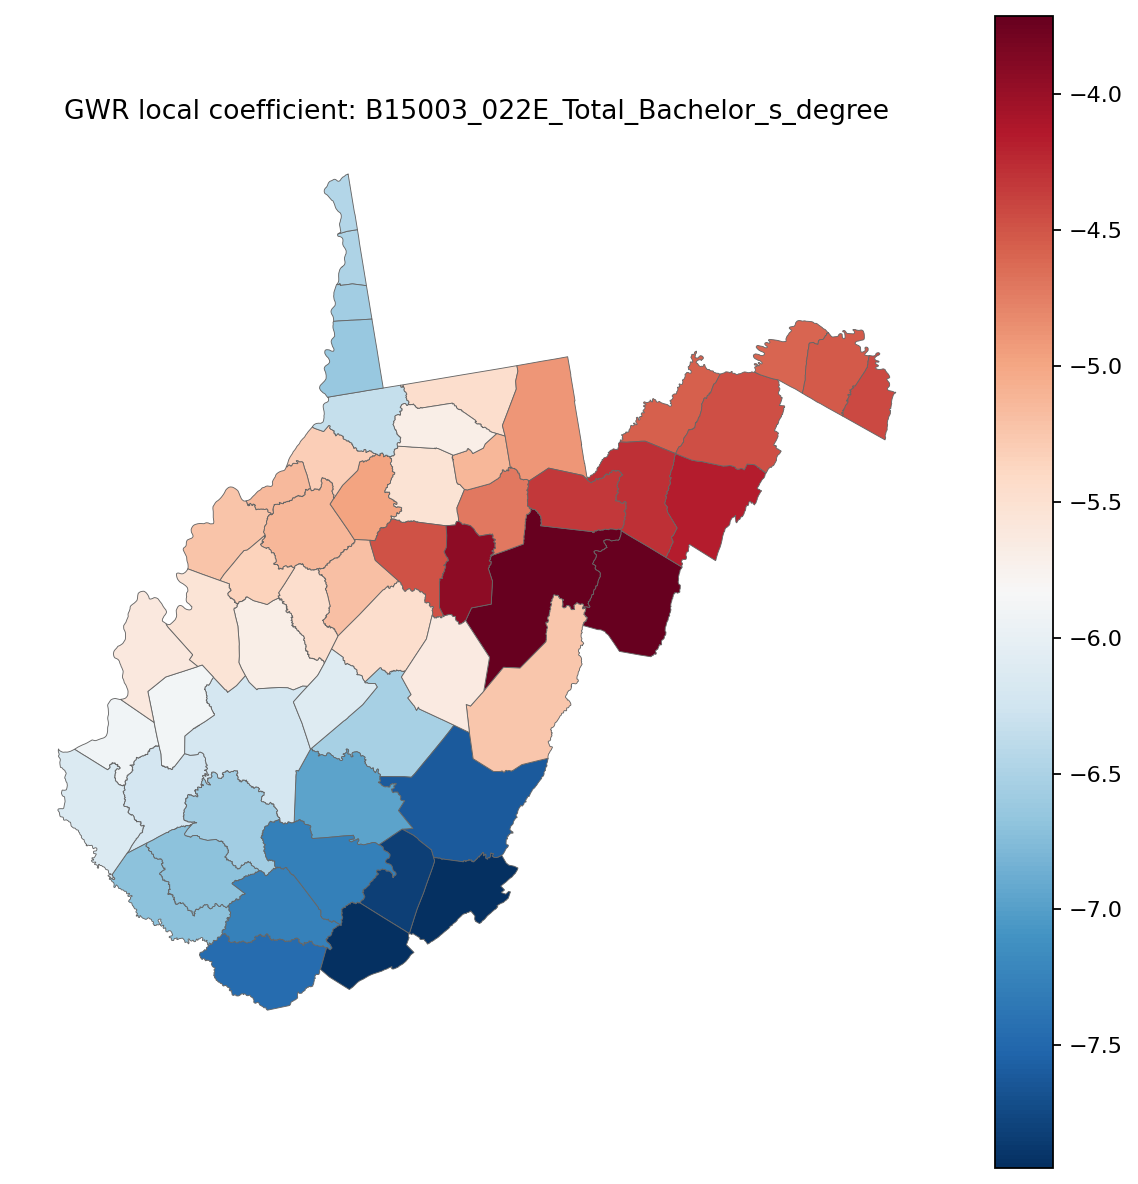

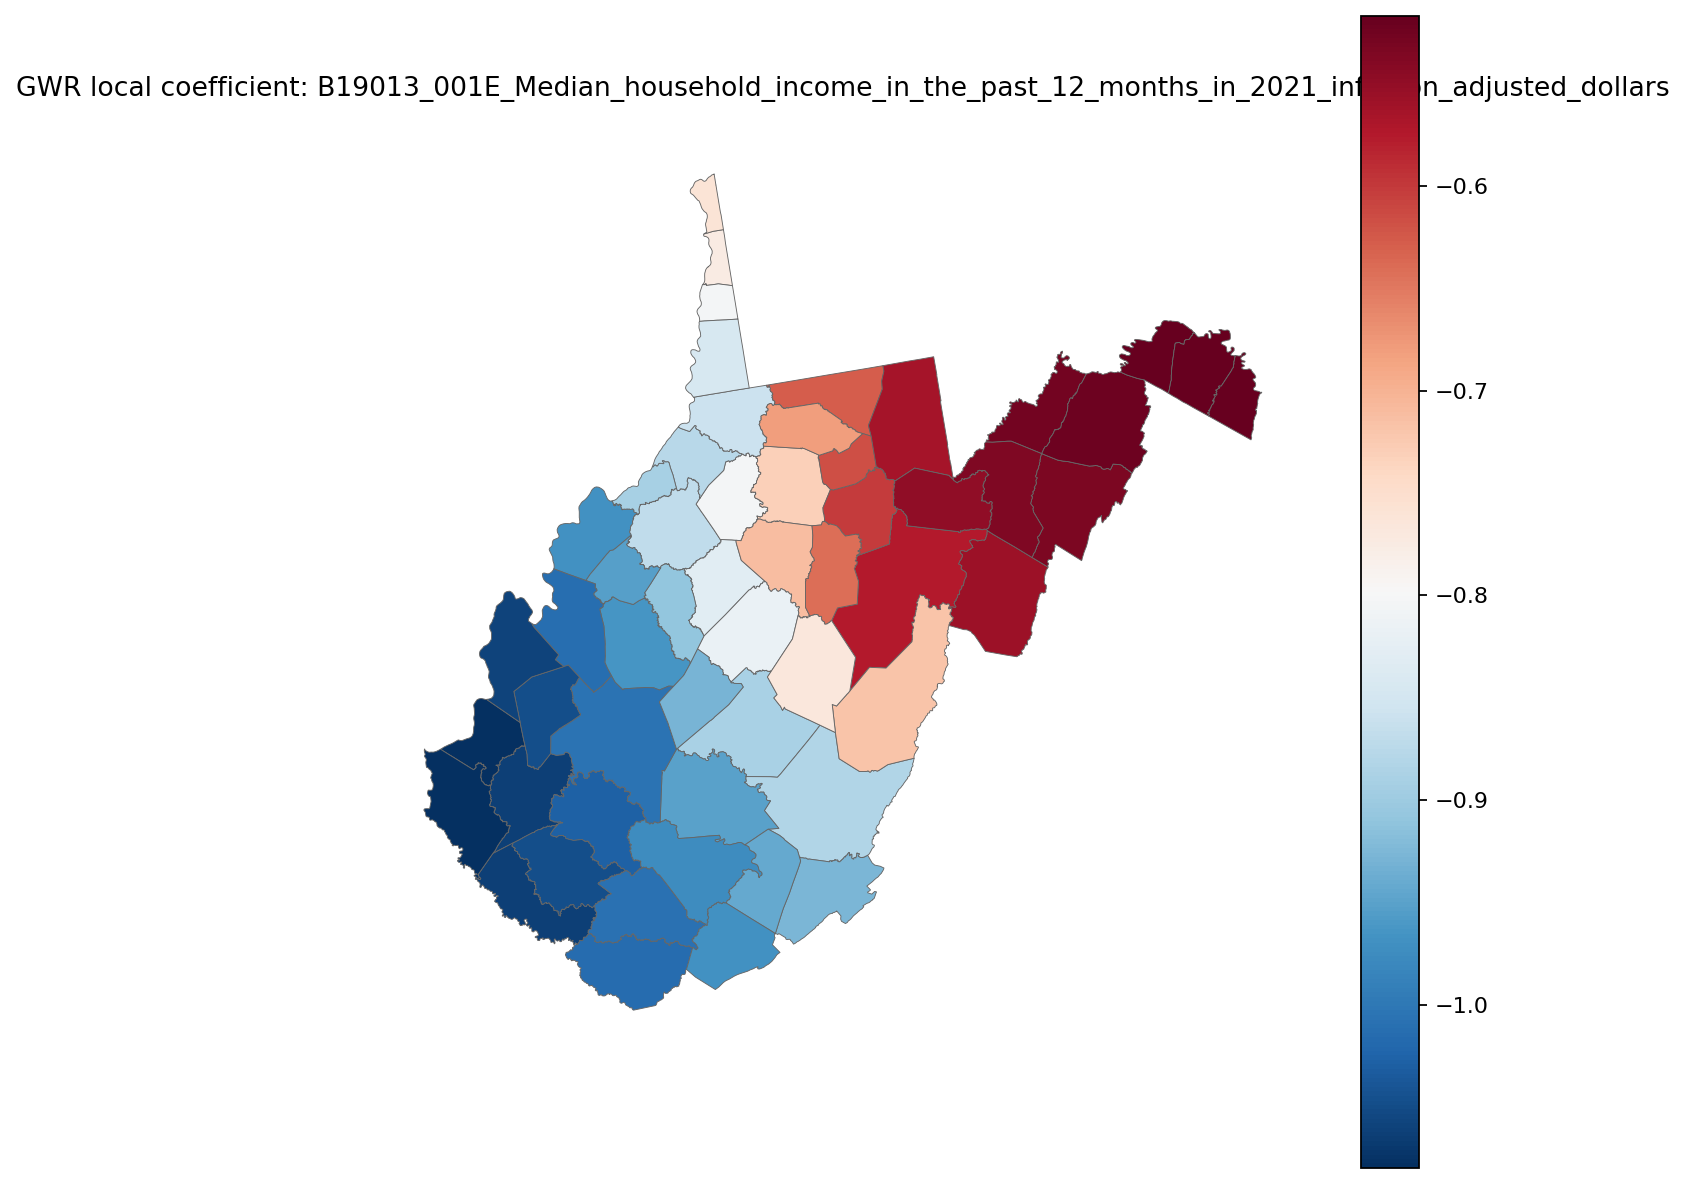

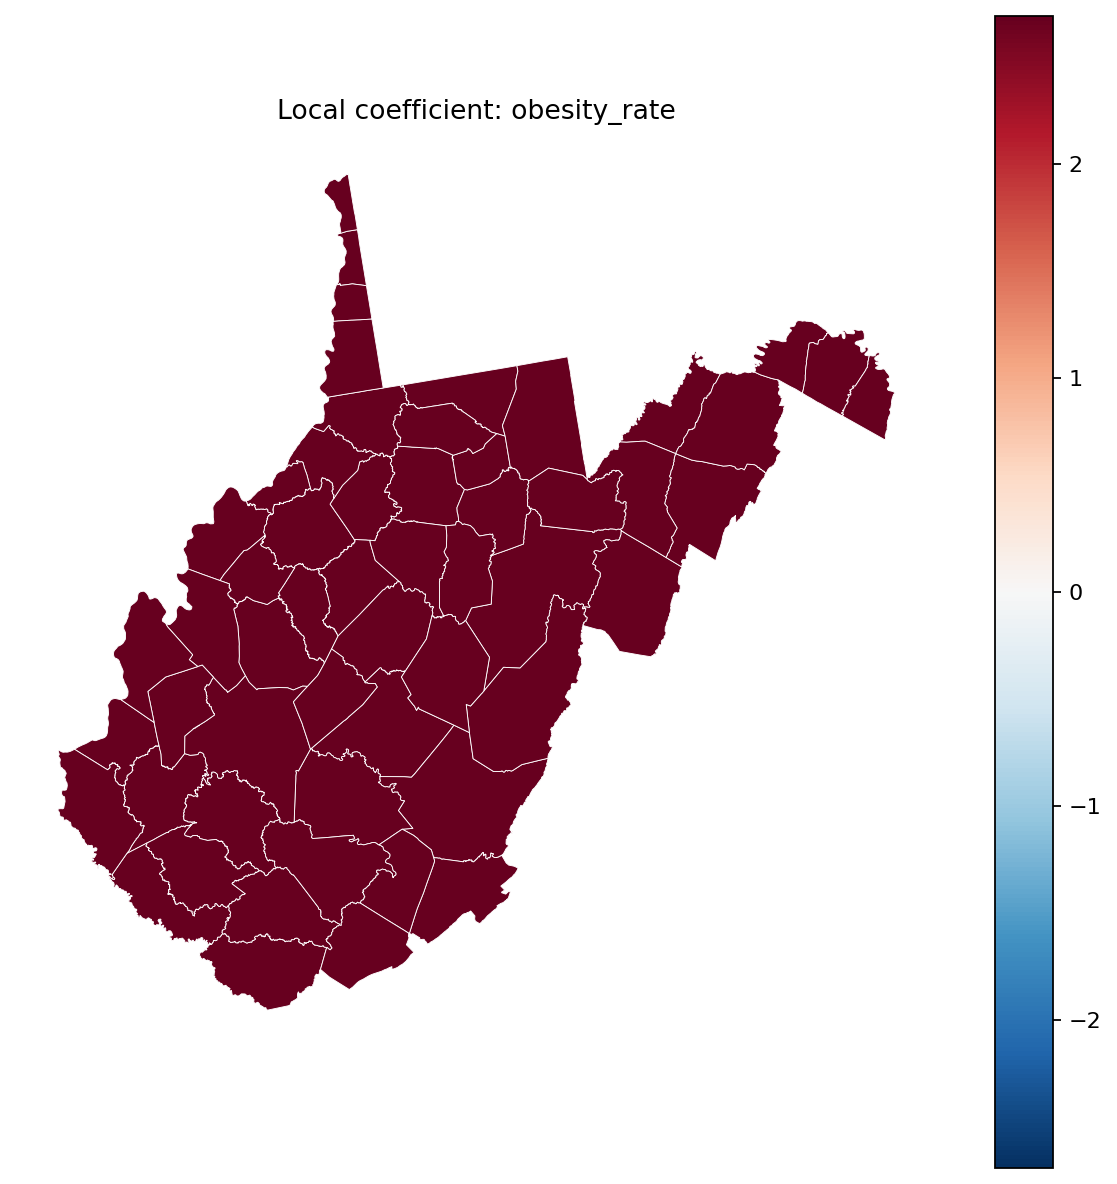

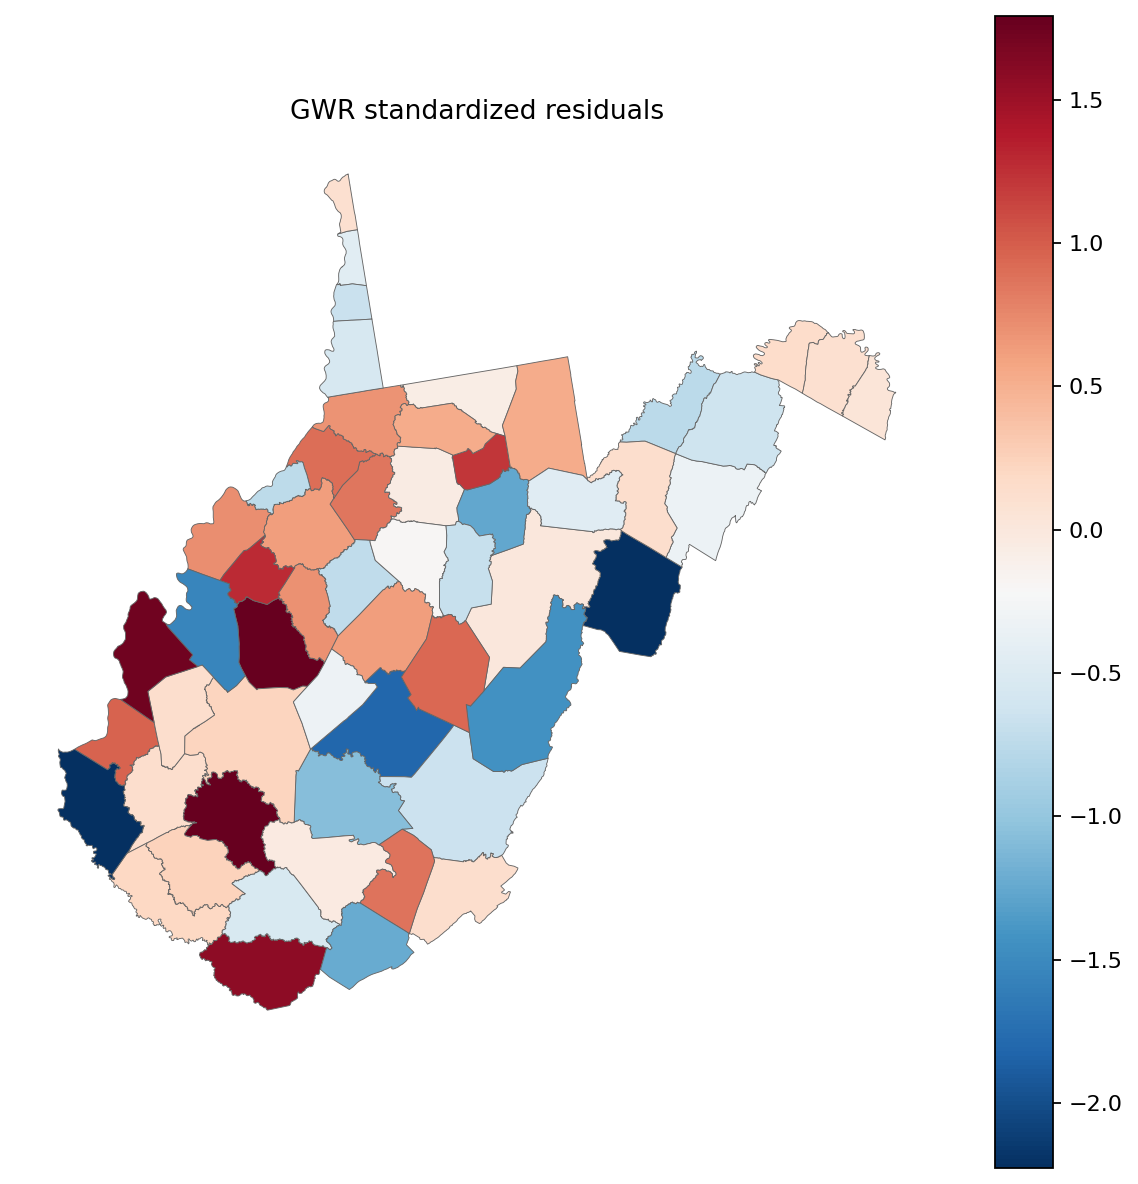

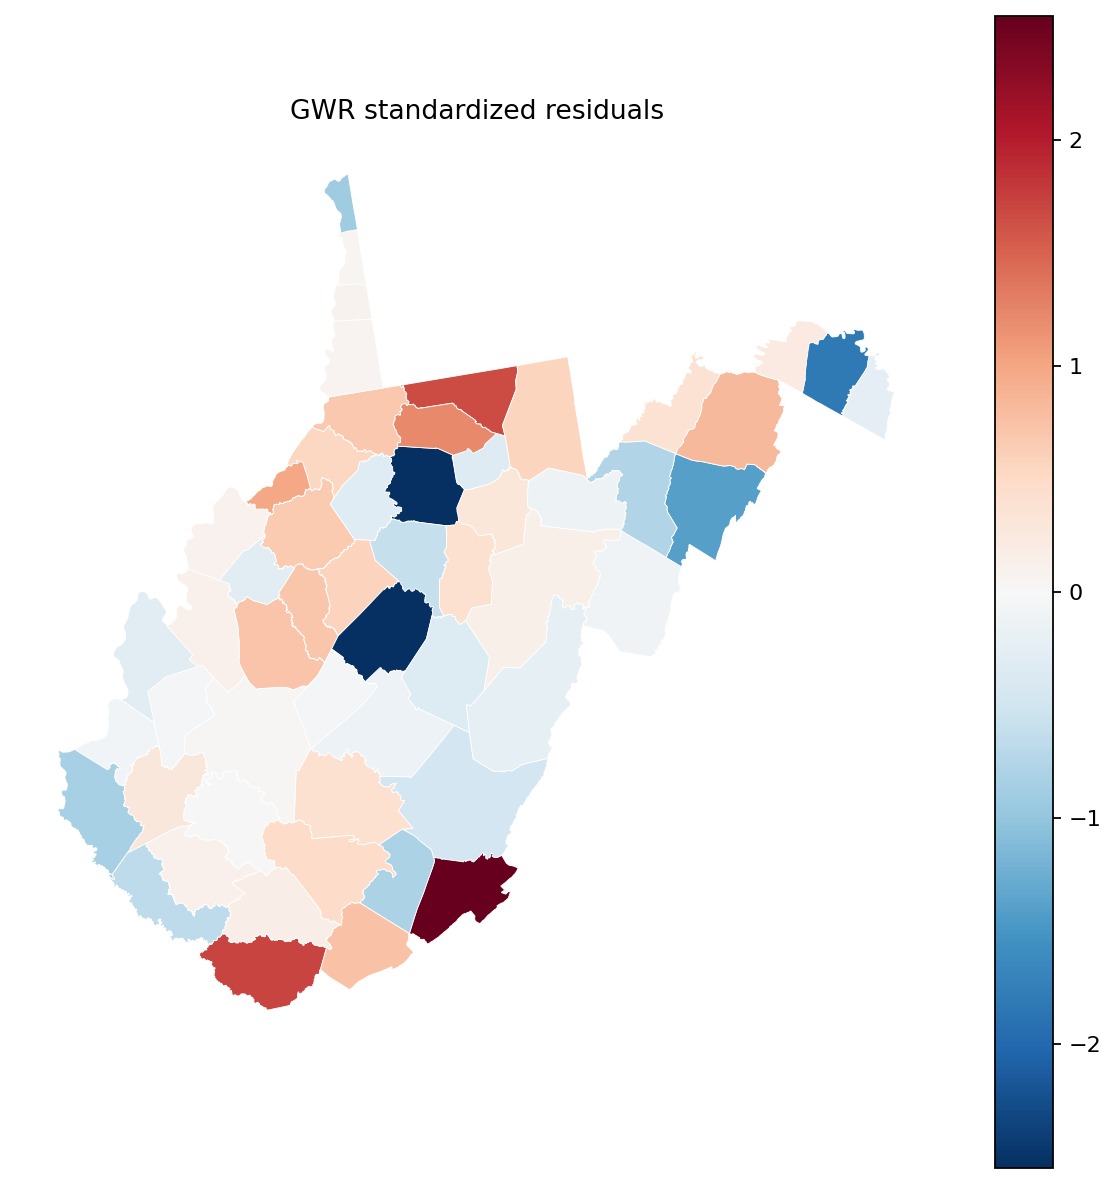

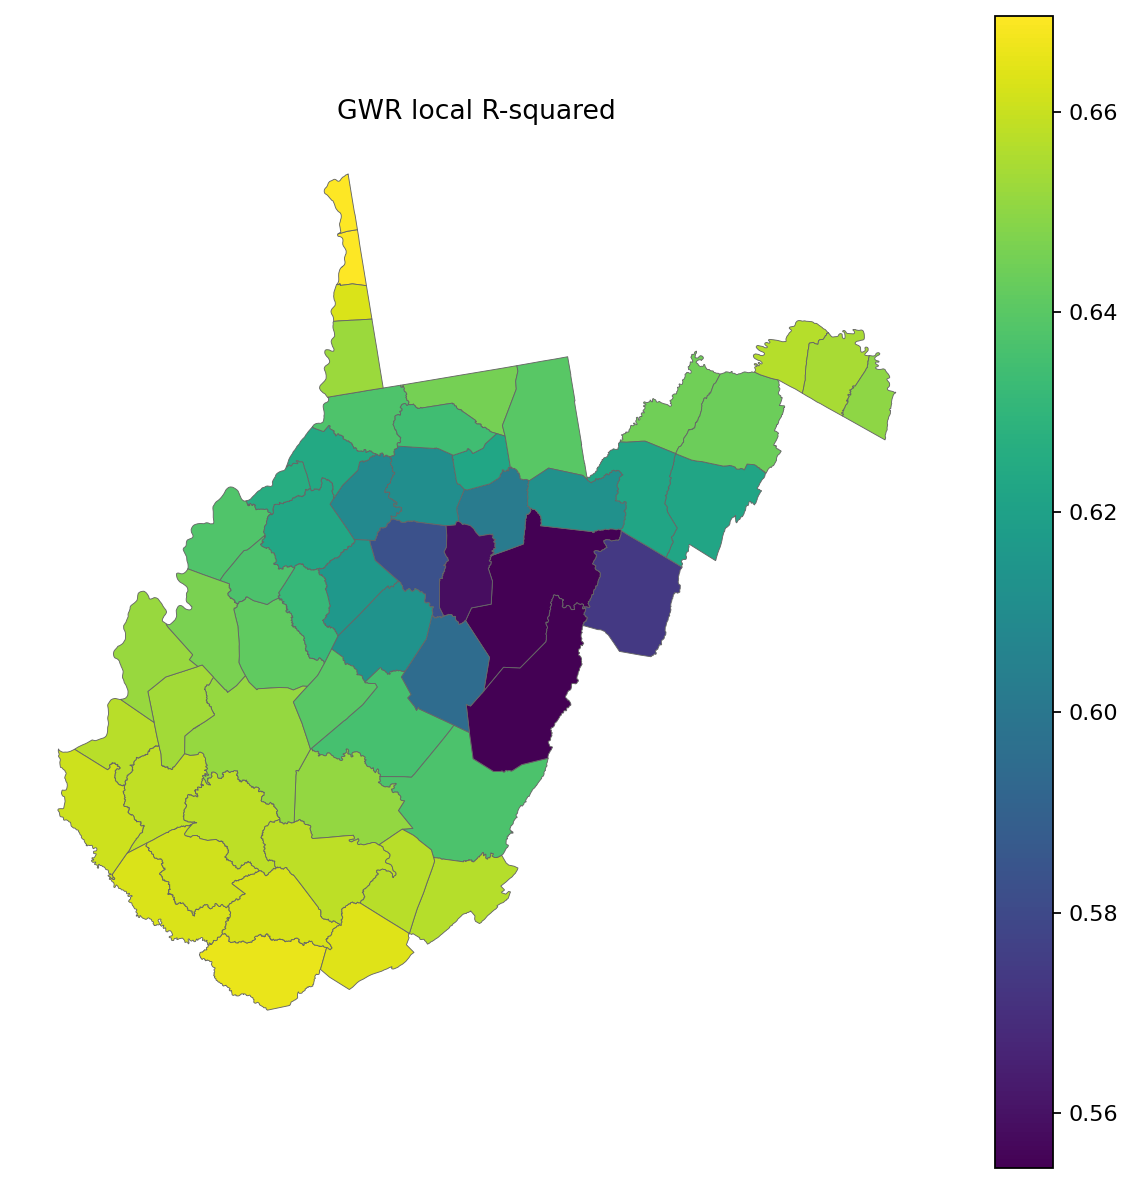

In [24]:
print("GWR mappable layer (-> mapping agent):", gwr_features_url)
print("GWR HTML summary report             :", gwr_report_url)

# Show the GWR summary report link and any maps/charts it produced
display_visual_artifacts(GWR_result)

## Part 7: Map the GWR Results

The mapping agent renders the GWR outputs from the vector layer produced above — the standardized residuals, local R-squared, and each local coefficient surface.


Map GWR Coefficients, Local R-squared, and Residuals
[21:40:26] stream_connected: Streaming connection established.
[21:40:26] Mapping Agent: I received your request.
[21:40:26] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:40:27] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[21:40:27] task_accepted: Task accepted. Starting streaming execution.
[21:40:27] Mapping Agent: Next I will run the agent with the prepared inputs.
[21:40:27] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[21:40:27] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[21:40:37] Mapping Agent: I'm still working. Long LLM calls, code execution, or geospatial file pr

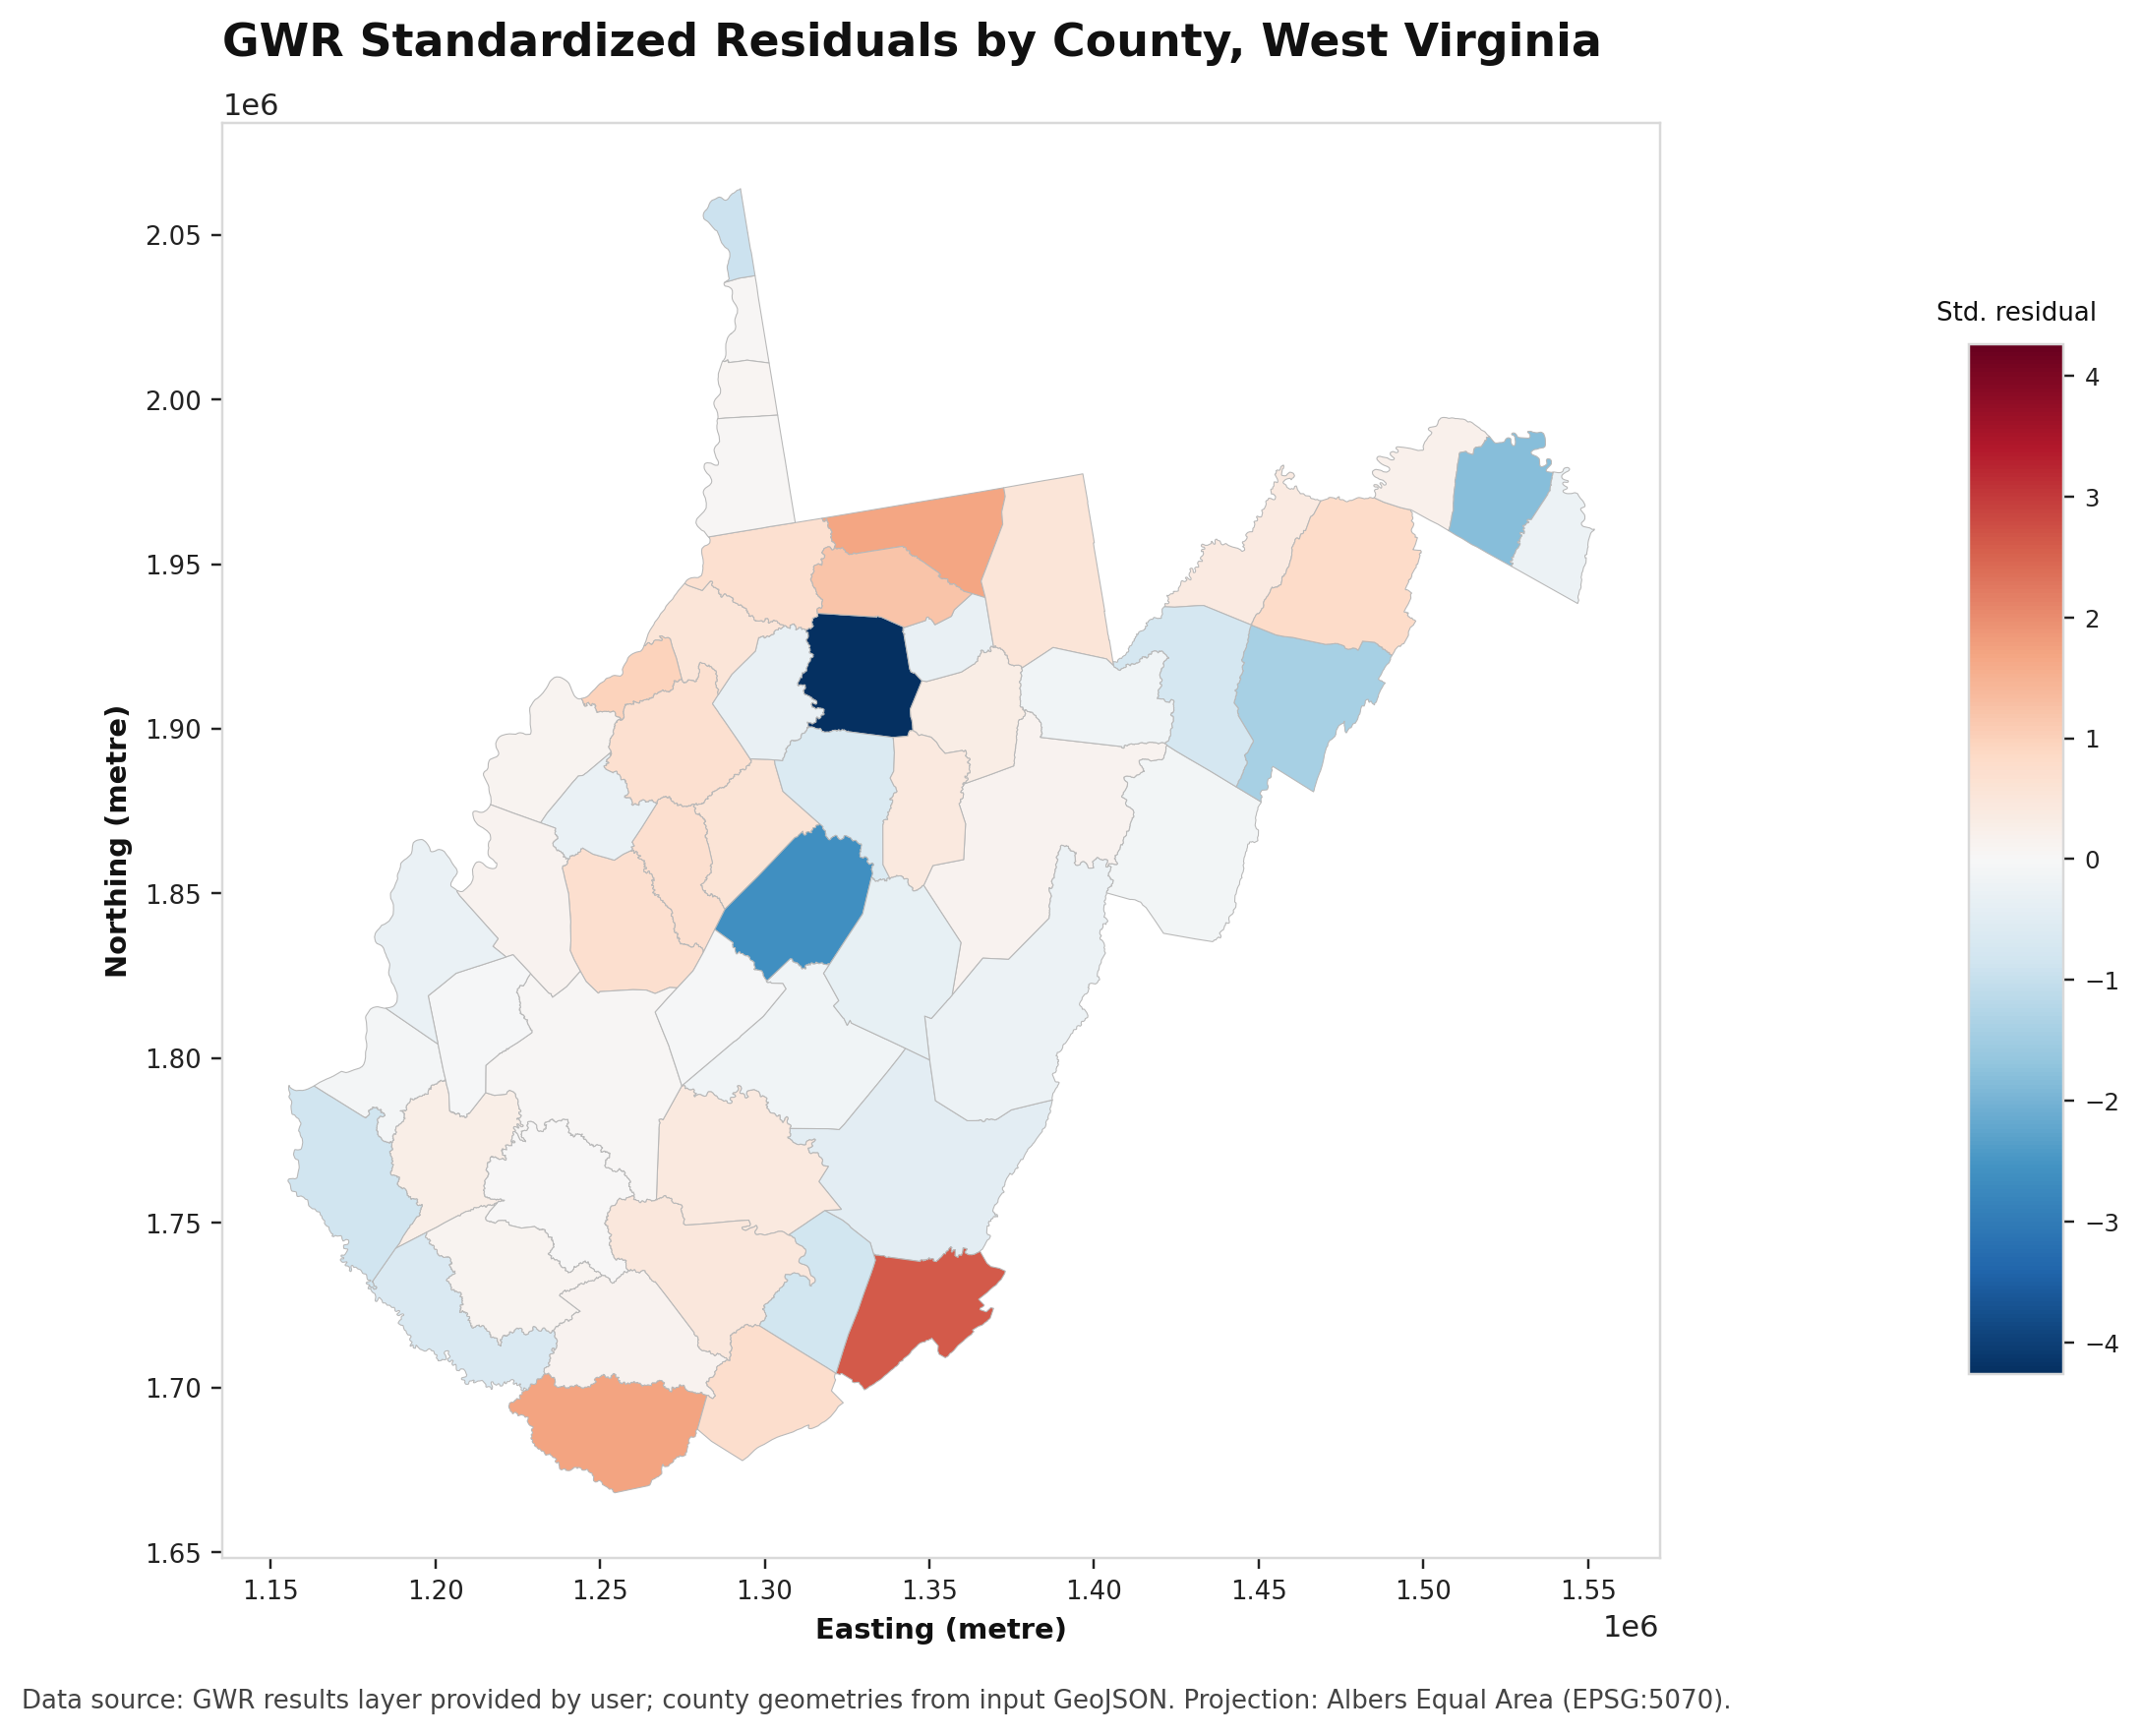

In [25]:
gwr_map_result = run_streaming_task(
    mapping_agent,
    (
        "Create professional county choropleth maps of West Virginia from the GWR results layer. "
        "Produce a set of maps: (1) the GWR standardized residuals (gwr_std_residual) using a diverging "
        "red-blue ramp centered at 0; (2) the local R-squared (local_r2) using a sequential ramp; and "
        "(3) one map per local coefficient column present (each coef_<variable>) using a diverging ramp "
        "centered at 0. Use the Albers Equal Area projection, thin county outlines, a legend and clear "
        "title for each map, and a data-source caption. Where t_<variable> columns exist, mark counties "
        "whose local t-value is significant (|t| > 1.96)."
    ),
    input_datasets=[gwr_features_url],
    title="Map GWR Coefficients, Local R-squared, and Residuals",
)

display_visual_artifacts(gwr_map_result)